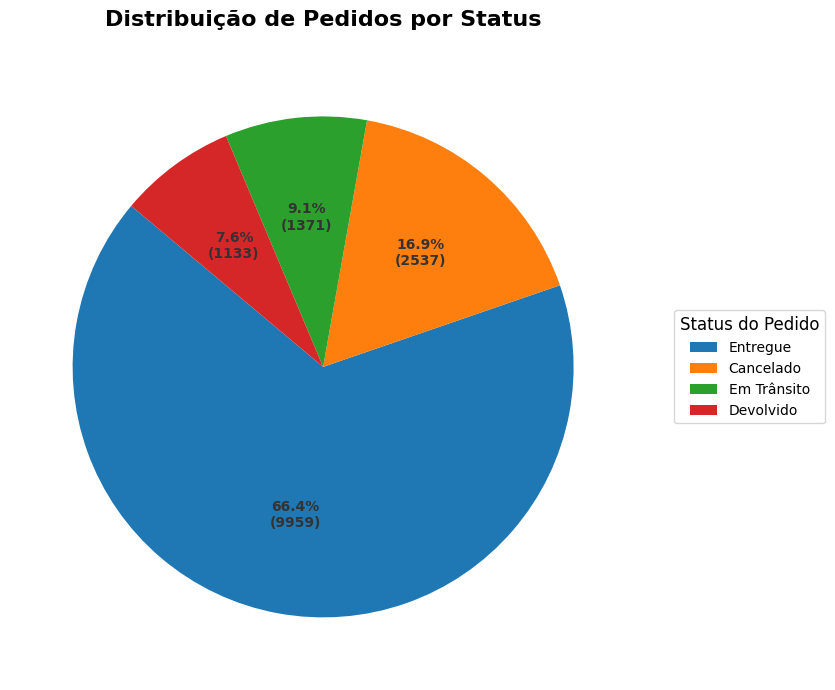

In [ ]:
# 1) Qual o volume de pedidos por status? Calcule a distribuição percentual e apresente os resultados em uma tabela. Inclua uma visualização gráfica (ex: gráfico de barras ou pizza).

import pandas as pd
import matplotlib.pyplot as plt

df_pedidos = pd.read_csv('../data/pedidos.csv')

mapeamento_status = {
    'em_transito': 'Em Trânsito',
    'entregue': 'Entregue',
    'cancelado': 'Cancelado',
    'aguardando_pagamento': 'Aguardando Pagamento',
    'devolvido': 'Devolvido'
}

df_pedidos['status'] = df_pedidos['status'].map(mapeamento_status).fillna(df_pedidos['status'].str.title())
volume_status = df_pedidos['status'].value_counts()

plt.figure(figsize=(10, 7)) 
plt.title('Distribuição de Pedidos por Status', fontsize=16, fontweight='bold', pad=20)

def formatar_autopct(valores):
    def formato(pct):
        total = sum(valores)
        valor_absoluto = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({valor_absoluto})'
    return formato

wedges, texts, autotexts = plt.pie(
    volume_status, 
    autopct=formatar_autopct(volume_status),
    startangle=140, 
    colors=plt.cm.tab10.colors[:len(volume_status)], 
    textprops={'fontsize': 10, 'fontweight': 'bold', 'color': '#333333'} 
)


plt.legend(
    wedges, 
    volume_status.index,
    title="Status do Pedido",
    title_fontsize=12,
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    frameon=True
)

plt.tight_layout()
plt.show()